## 1. Encàrrec de productora
<p><img src="https://cdn.pixabay.com/photo/2018/10/09/00/21/netflix-3733812_960_720.jpg" alt="foto pelicula"></p>
<p>Una de les productores més importants del mercat ens ha demant fer un anàlisis històric abans d'invertir en una nova pel·lìcula.</p>
<p>Haurem de donar repsposta a diferents preguntes com: </p>

*   La popularitat de les pel·lícules han disminuït durant els anys
*   Quins gènere tenen millor valoracions
*   Les pel·lícules que ofereixen un millor benefici proporcional son les de més pressupost
*   Quins gèneres ofereixen més benefici.
*   Proposa una idea de pel·lìcula
*   Surt a compte fer una segona part?

<p>Per realitzar aquest anàlisis disposem dels següents set de dades:.</p>

*  movies.p: pel·lìcula data i espectadors
*   movie_to_genres.p: gènere de cada pel·lìcula
*   financial.p: dades econòmiques de cada pel·lìcula
*   sequels.p: relació de les pelìcules i les seves sequeles.
*   ratings.p: valoració de les pel·lìcules






---



## Anàlisis de la popularitat

L'empresa creu que durant els darrers anys les pel·lícules tenen menys popularitat. Vol que ho comprovem gràficament

Primer de tot importarem el nostre dataset i analitzarem les seves dades bàsiques ¿Quina es la popularitat mitja i la més alta?

In [726]:
import pandas as pd
import numpy as np

actors_data = pd.read_csv('actors_movies.csv')
financials_data = pd.read_pickle('financials.p')
genres_data = pd.read_pickle('movie_to_genres.p')
movies_data = pd.read_pickle('movies.p')
ratings_data = pd.read_pickle('ratings.p')
sequels_data = pd.read_pickle('sequels.p')

movies_data.head()
print("Popularitat mitjana:", movies_data['popularity'].mean())
print("Popularitat més alta:", movies_data['popularity'].max())

Popularitat mitjana: 21.492300588174057
Popularitat més alta: 875.581305


Necessitem treballar amb el camp release_date com a datatime, així que transformem la columna i ho comprovem. ¿De quin fins a quin any tenim dades?

In [727]:
movies_data['release_date'] = pd.to_datetime(movies_data['release_date'])

print(movies_data['release_date'].min())
print(movies_data['release_date'].max())

1916-09-04 00:00:00
2017-02-03 00:00:00


L'empresa considera que els gustos han canviat molt durant els últims anys, aixi que nomès l'interessen les dades desde el 2010. ¿De cuàntes dades disposem? ¿De cuàntes dades disposem?

In [728]:
movies_recent = movies_data[movies_data['release_date'].dt.year >= 2010]

print(f"Disposem de {movies_data.shape[0]} dades, {movies_recent.shape[0]} de les quals són de després del 2010")

Disposem de 4803 dades, 1446 de les quals són de després del 2010


Pasem a mostrar la linea temporal de com ha variat la popularitat durant els darrers anys.

<Axes: xlabel='release_date'>

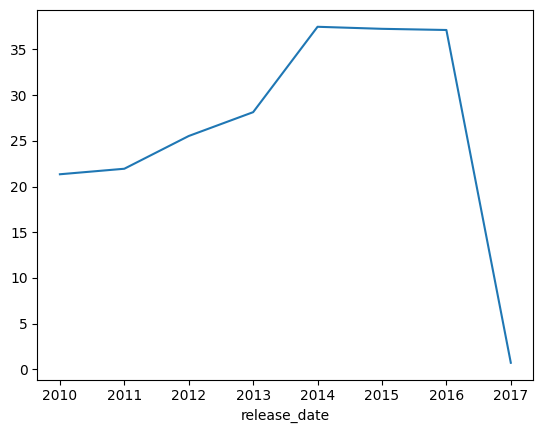

In [729]:
movies_popularity_by_year = movies_recent.groupby(movies_recent['release_date'].dt.year)['popularity'].mean()

movies_popularity_by_year.plot(kind='line')

¿Què passa al 2017, quin és el motiu? Igualment aquesta devadalla és molt extranya, és probalble a que en alguns anys s'hagin realitzat moltes més pel·lícules i que per aquesta raó la mitja sigui molt més alta. Anem a fer el mateix procediment amb la mitja

<Axes: xlabel='release_date'>

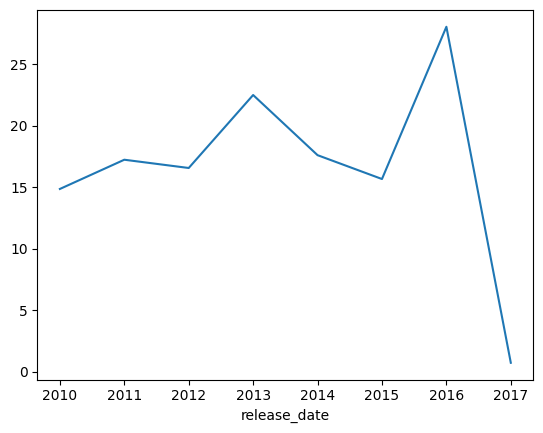

In [730]:
movies_popularity_by_year = movies_recent.groupby(movies_recent['release_date'].dt.year)['popularity'].median()

movies_popularity_by_year.plot(kind='line')

### Resposta 1. Estan perdent popularitat les pel·lìcules?

No, però sembla que hi ha hagut un error amb les dades de l'any 2017. De fet, estan pujant en popularitat.
---



## Anàlisis del rating

Un cop decidit que val la pena realitzar una pel·lìcula, haurem de valorar de quina gènere val la pena en funció de la seva valoració. Primer de tot mostrarem la puntuació mitja de les pel·lícules i les 10 pel·lìcules més valorades. Mostra únicament el nom i el títol de la pel·lìcula ( i el index que surt per defecte)

In [731]:
from functools import reduce

# List of dataframes
dfs = [financials_data, movies_data, ratings_data]

# Merge all dataframes on the 'id' column
all_data = reduce(lambda left, right: pd.merge(left, right, on='id', how='outer'), dfs)

# Median rating of all movies
mean_rating = all_data['vote_average'].mean()

print("Puntuació mitja:", mean_rating)

# Get the top 10 movies
top_movies = all_data.sort_values(by='vote_count', ascending=False)['title']
top_movies.head(10)

Puntuació mitja: 6.092171559442016


,title
2955,Inception
68,The Dark Knight
2702,Avatar
2861,The Avengers
4593,Deadpool
4170,Interstellar
3703,Django Unchained
4057,Guardians of the Galaxy
3723,The Hunger Games
3801,Mad Max: Fury Road


De les pel·lìcules que ens interessa pel nostre anàlisis ( més de 60k de popularitat i més de 2000 valoracions) obtindrem el seu gènere per mostra gràficament la mitja per gènere.

/tmp/ipython-input-920288480.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  worthy_movies = all_data[all_data['vote_count'] >= 2000][all_data['popularity'] >= 60]


<Axes: xlabel='genre'>

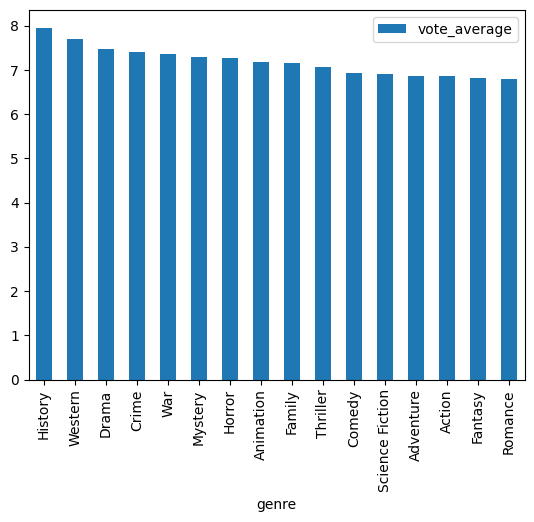

In [732]:
worthy_movies = all_data[all_data['vote_count'] >= 2000][all_data['popularity'] >= 60]

worthy_movies = pd.merge(worthy_movies, genres_data, left_on='id', right_on='movie_id')

worthy_movies.head()

worthy_movies_by_genre = worthy_movies.groupby('genre')[['genre', 'vote_average']].mean('vote_average').sort_values('vote_average', ascending=False)

worthy_movies_by_genre.plot(kind='bar')

¿Quin és el motiu que els tamany dels dataset siguin diferents?

Cada pel·lícula té més d'un gènere

¿Quins son el tres gèneres amb millor valoració?

Historia, Western i Drama



---



## Anàlisis econòmic

Observa el dataset financial i els seus estadìstics bàsics. ¿Quin és el pressupost i els ingressos promig?¿Sembla rentable fer una pel·lìcula?

In [733]:
promig = all_data[['budget', 'revenue']].mean()

print("Pressupost promig:", promig['budget'])
print("Ingressos promig:", promig['revenue'])

print("si es rentable :)")

Pressupost promig: 40654444.774233505
Ingressos promig: 121242957.26138124
si es rentable :)


Mostra la distribució (histograma) del pressupost de les pel·lícules. ¿La majoria de pel·lìcules son de baix o alt pressupost?


Budget Statistics:
count    3.229000e+03
mean     4.065444e+07
std      4.439674e+07
min      1.000000e+00
25%      1.050000e+07
50%      2.500000e+07
75%      5.500000e+07
max      3.800000e+08
Name: budget, dtype: float64
La majoria són de baix pressupost


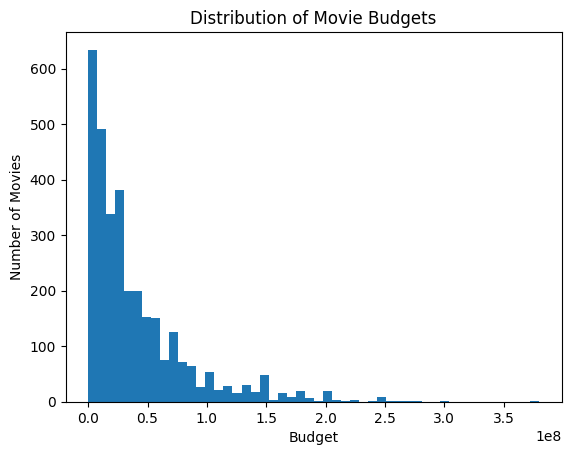

In [734]:
# This creates the histogram directly from the column
ax = all_data['budget'].plot.hist(bins=50, title='Distribution of Movie Budgets')
ax.set_xlabel('Budget')
ax.set_ylabel('Number of Movies')

print("\nBudget Statistics:")
print(all_data['budget'].describe())
print("La majoria són de baix pressupost")

Más de la mitad de peliculas tienen un presupuesto entre 0 y 50 millones.

Si

Volem mostrar ( nom inclòs) les pel·lìcules les 5 pel·lícules mès profitosses i les 5 més deficitàries de la historia.

In [735]:
# Create the profit column using vectorization
all_data['profit'] = all_data['revenue'] - all_data['budget']

# Sort and display
profit_movies = all_data.sort_values(by='profit', ascending=False)
print(profit_movies.head(5))
print(profit_movies.tail(5))

          id       budget       revenue           title  popularity  \
2702   19995  237000000.0  2.787965e+09          Avatar  150.437577   
256      597  200000000.0  1.845034e+09         Titanic  100.025899   
4108  135397  150000000.0  1.513529e+09  Jurassic World  418.708552   
4204  168259  190000000.0  1.506249e+09       Furious 7  102.322217   
2861   24428  220000000.0  1.519558e+09    The Avengers  144.448633   

     release_date  vote_average  vote_count        profit  
2702   2009-12-10           7.2     11800.0  2.550965e+09  
256    1997-11-18           7.5      7562.0  1.645034e+09  
4108   2015-06-09           6.5      8662.0  1.363529e+09  
4204   2015-04-01           7.3      4176.0  1.316249e+09  
2861   2012-04-25           7.4     11776.0  1.299558e+09  
          id  budget  revenue                        title  popularity  \
4798  426067     NaN      NaN             Midnight Cabaret    0.001389   
4799  426469     NaN      NaN             Growing Up Smith    0.7

No tenim clar si és convenient realitzar una pel·lícula d'alt o baix pressupost, per aquesta raó anem a comparar si existeix una correlació entre el pressupost i el pro_profit guanyat. Podriem mostra una matriu de correlació, pero preferim extreu conclusions visuals a través d'un scatter plot. Et dona la sensació que si s'inverteixen més diner la proporció de benefici és més gran?

<Axes: xlabel='budget', ylabel='profit'>

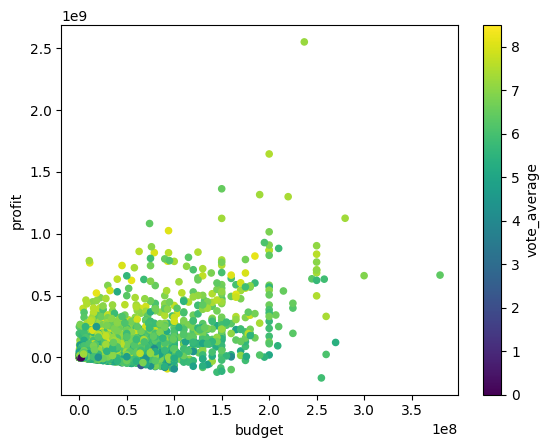

In [736]:
all_data.plot.scatter('budget', 'profit', c='vote_average')

En la mateixa gràfica anem incloure les valoracions de les pel·lìcules, aparentment imaginem que les pel·lìcules que han tingut bona acollida son les que mé beneficis han aportat. Veient la gràfica creada sembla certa aquesta afirmaciò?

Com a norma general, sí, les pel·lícules millor valorades també són les que han rebut més beneficis.

Finalment per determinar quina tipus de pel·lìcula realitzarem visualitzarem els gèneres que ofereixen millor relació en quant a proporció de benefici. Mirant l'apartat anterior i aquest, quin seria els gèneres de la teva pel·lìcula? Fica imagina i proposa una temàtica.

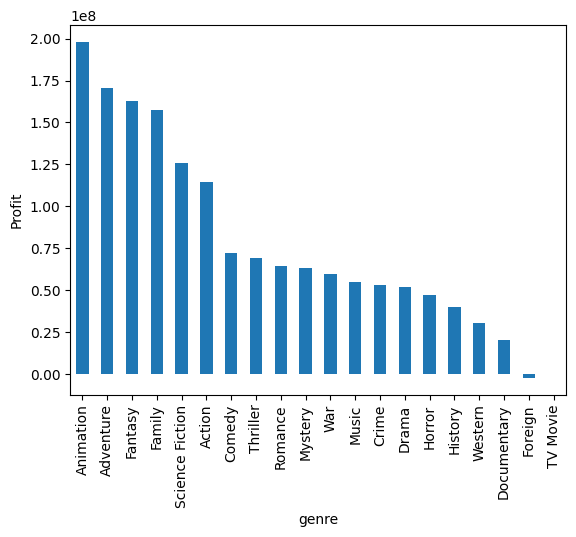

In [737]:
genre_profit = pd.merge(all_data, genres_data, left_on='id', right_on='movie_id').groupby('genre')['profit'].mean('profit').sort_values(ascending=False).plot.bar().set_ylabel('Profit')

## 'Segundas partes no son buenas'

La nostra pel·lìcula ha tingut molt bona acollida tant que estem valorant la possibilitat de realitzar una segona part. Existeix la idea de que les seqüeles son sempre pitjors. Mostra la diferència promig entre les pel·lìcules i les seves seqüeles i les 5 pel·lìcules on les seves continuacions han millorat mès.

In [738]:
# Mostrem dataset
sequels_data.dropna(inplace=True)

# Afegir sequel IDs al DataFrame
all_sequel = all_data.merge(
    sequels_data[['id', 'sequel']],
    on='id',
    how='left'
)

# Canviar sequel IDs amb els títols
all_sequel = all_sequel.merge(
    all_data[['id', 'title']],
    left_on='sequel',
    right_on='id',
    how='left',
    suffixes=('', '_sequel')
).drop(columns=['id_sequel'])

all_sequel.head()

# Elimina files que no tenen sequel
all_sequel.dropna(inplace=True)

# comprova que no hi ha NA
all_sequel.head()

# simplifiquem per quedar-nos únicament amb id_original, titol_original, id_sequel, titol_sequel
all_sequel = all_sequel[['id', 'title', 'sequel', 'title_sequel']]
all_sequel.rename(columns={'id': 'id_original', 'title': 'title_original', 'sequel': 'id_sequel'}, inplace=True)
all_sequel.head()

,id_original,title_original,id_sequel,title_sequel
9,22,Pirates of the Caribbean: The Curse of the Bla...,58,Pirates of the Caribbean: Dead Man's Chest
29,76,Before Sunrise,80,Before Sunset
33,80,Before Sunset,132344,Before Midnight
36,87,Indiana Jones and the Temple of Doom,89,Indiana Jones and the Last Crusade
37,89,Indiana Jones and the Last Crusade,217,Indiana Jones and the Kingdom of the Crystal S...


In [739]:
# Merge per duplicat per obentenir les valoracions
# creem nova columna amb la diferenta valoracació sequel i original
sequel_ratings = all_sequel.merge(
    all_data[['id', 'vote_average']],
    left_on='id_original',
    right_on='id',
    how='left'
).rename(columns={'vote_average': 'rating_original'}).drop(columns='id')

sequel_ratings = sequel_ratings.merge(
    all_data[['id', 'vote_average']],
    left_on='id_sequel',
    right_on='id',
    how='left'
).rename(columns={'vote_average': 'rating_sequel'}).drop(columns='id')

sequel_ratings.head()

,id_original,title_original,id_sequel,title_sequel,rating_original,rating_sequel
0,22,Pirates of the Caribbean: The Curse of the Bla...,58,Pirates of the Caribbean: Dead Man's Chest,7.5,7.0
1,76,Before Sunrise,80,Before Sunset,7.7,7.6
2,80,Before Sunset,132344,Before Midnight,7.6,7.4
3,87,Indiana Jones and the Temple of Doom,89,Indiana Jones and the Last Crusade,7.1,7.6
4,89,Indiana Jones and the Last Crusade,217,Indiana Jones and the Kingdom of the Crystal S...,7.6,5.7


In [740]:
# Mostra les 5 millor sequeles en comparació a la seva predecesora
sequel_ratings['sequel_superiority'] = sequel_ratings['rating_sequel'] - sequel_ratings['rating_original']
sequel_ratings.sort_values('sequel_superiority', ascending=False, inplace=True)
sequel_ratings.head()

,id_original,title_original,id_sequel,title_sequel,rating_original,rating_sequel,sequel_superiority
56,9355,Mad Max Beyond Thunderdome,76341,Mad Max: Fury Road,5.9,7.2,1.3
36,1771,Captain America: The First Avenger,100402,Captain America: The Winter Soldier,6.6,7.6,1.0
69,10676,Halloween III: Season of the Witch,11357,Halloween 4: The Return of Michael Myers,5.0,5.9,0.9
70,10764,Quantum of Solace,37724,Skyfall,6.1,6.9,0.8
12,331,Jurassic Park III,135397,Jurassic World,5.7,6.5,0.8




---



## UPGRADE - CASTING


A partir del dataset actors, fes l'anàlisis que consideris adient per escollir els nostres actors/actrius

In [741]:
# Merge and drop the redundant title column immediately
movies_actors = all_data.merge(
    actors_data[['Title', 'Actor']],
    left_on='title',
    right_on='Title',
    how='inner'
).drop(columns=['Title'])

# Clean and convert string representation of list to actual list
# Standardizes by removing brackets and quotes before splitting
movies_actors['Actor'] = (
    movies_actors['Actor']
    .str.replace(r"[\[\]']", "", regex=True)
    .str.split(',')
)

# Reassign the exploded dataframe to the variable
movies_actors = movies_actors.explode('Actor')

# Trim potential whitespace from names after split
movies_actors['Actor'] = movies_actors['Actor'].str.strip()

# Rebem els actors que més han sortit a pel·lícules, seràn els més famosos
movies_actors.groupby('Actor')['id'].count().sort_values(ascending=False)

,id
Actor,
Tom Hanks,9
Keanu Reeves,6
Hugo Weaving,5
Jack Nicholson,5
Cuba Gooding Jr.,4
...,...
Stephen Rea,1
Susan Sarandon,1
Tom Skerritt,1
